In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score, classification_report)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")  # 0 = malignant, 1 = benign
target_names = {0: "Malignant", 1: "Benign"}

print("Samples, Features:", X.shape)
print("Missing values:", X.isnull().sum().sum())
print("\nClass distribution:")
print(y.map(target_names).value_counts())


Samples, Features: (569, 30)
Missing values: 0

Class distribution:
target
Benign       357
Malignant    212
Name: count, dtype: int64


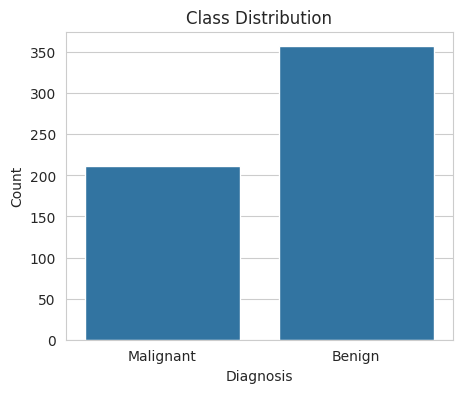

In [3]:
plt.figure(figsize=(5, 4))
sns.countplot(x=y.map(target_names))
plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, " Test shape:", X_test_scaled.shape)


Train shape: (455, 30)  Test shape: (114, 30)


In [5]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

explained = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained)

n_components_95 = np.argmax(cum_explained >= 0.95) + 1
print(f"Components needed for 95% variance: {n_components_95} (out of {X_train_scaled.shape[1]} original features)")
print(f"Explained variance at {n_components_95} components: {cum_explained[n_components_95-1]*100:.2f}%")


Components needed for 95% variance: 10 (out of 30 original features)
Explained variance at 10 components: 95.27%


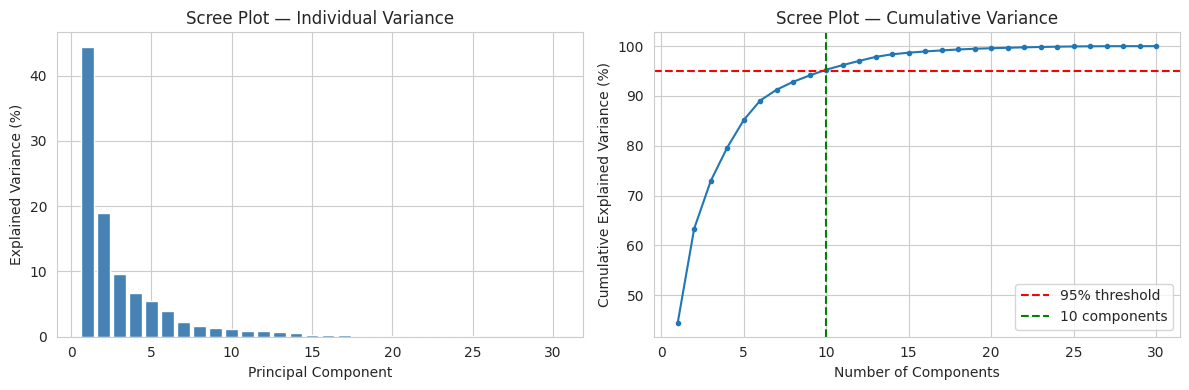

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(explained)+1), explained*100, color="steelblue")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Scree Plot — Individual Variance")

axes[1].plot(range(1, len(cum_explained)+1), cum_explained*100, marker="o", markersize=3)
axes[1].axhline(95, color="red", linestyle="--", label="95% threshold")
axes[1].axvline(n_components_95, color="green", linestyle="--", label=f"{n_components_95} components")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance (%)")
axes[1].set_title("Scree Plot — Cumulative Variance")
axes[1].legend()

plt.tight_layout()
plt.show()


In [7]:
pca = PCA(n_components=n_components_95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

pca_summary = pd.DataFrame({
    "Setting": ["With-PCA"],
    "Chosen Components / Variance Target": [f"{n_components_95} components (95% variance target)"],
    "Explained Variance (%)": [round(cum_explained[n_components_95-1]*100, 2)],
    "Justification": ["95% cumulative variance retains most of the information while cutting the feature count roughly in half"],
})
pca_summary


,Setting,Chosen Components / Variance Target,Explained Variance (%),Justification
0,With-PCA,10 components (95% variance target),95.27,95% cumulative variance retains most of the in...


In [8]:
base_estimators_for_stacking = [
    ("svm", SVC(probability=True, random_state=RANDOM_STATE)),
    ("rf", RandomForestClassifier(random_state=RANDOM_STATE)),
    ("knn", KNeighborsClassifier()),
]

models_and_grids = {
    "SVM": (
        SVC(probability=True, random_state=RANDOM_STATE),
        {"kernel": ["linear", "rbf"], "C": [0.1, 1, 10], "gamma": ["scale", 0.01, 0.1]}
    ),
    "Naive Bayes": (
        GaussianNB(),
        {"var_smoothing": [1e-9, 1e-8, 1e-7]}
    ),
    "KNN": (
        KNeighborsClassifier(),
        {"n_neighbors": [3, 5, 7, 9], "weights": ["uniform", "distance"], "metric": ["euclidean", "manhattan"]}
    ),
    "Logistic Regression": (
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        {"C": [0.01, 0.1, 1, 10], "penalty": ["l2"]}
    ),
    "Decision Tree": (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {"max_depth": [3, 5, 7, None], "min_samples_split": [2, 5, 10]}
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {"n_estimators": [100, 200], "max_depth": [5, 10, None]}
    ),
    "AdaBoost": (
        AdaBoostClassifier(random_state=RANDOM_STATE),
        {"n_estimators": [50, 100, 200], "learning_rate": [0.01, 0.1, 1.0]}
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [2, 3]}
    ),
    "XGBoost": (
        XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0),
        {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [3, 5]}
    ),
    "Stacking": (
        StackingClassifier(estimators=base_estimators_for_stacking,
                            final_estimator=LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
                            cv=5, n_jobs=-1),
        {"final_estimator__C": [0.1, 1, 10]}
    ),
}

print("Models defined:", list(models_and_grids.keys()))


Models defined: ['SVM', 'Naive Bayes', 'KNN', 'Logistic Regression', 'Decision Tree', 'Random Forest', 'AdaBoost', 'Gradient Boosting', 'XGBoost', 'Stacking']


In [9]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def tune_and_get_fold_scores(model, param_grid, X, y, cv):
    grid = GridSearchCV(model, param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
    grid.fit(X, y)
    best_model = grid.best_estimator_

    fold_scores = cross_validate(best_model, X, y, cv=cv, scoring=["accuracy", "f1"], n_jobs=-1)
    return {
        "best_params": grid.best_params_,
        "fold_accuracy": fold_scores["test_accuracy"],
        "avg_accuracy": fold_scores["test_accuracy"].mean(),
        "fold_f1": fold_scores["test_f1"],
        "avg_f1": fold_scores["test_f1"].mean(),
        "best_estimator": best_model,
    }


In [10]:
results_no_pca = {}
results_with_pca = {}

for name, (model, grid) in models_and_grids.items():
    t0 = time.time()
    results_no_pca[name] = tune_and_get_fold_scores(model, grid, X_train_scaled, y_train, cv5)
    results_with_pca[name] = tune_and_get_fold_scores(model, grid, X_train_pca, y_train, cv5)
    print(f"{name:22s} done in {time.time()-t0:5.1f}s | "
          f"No-PCA acc={results_no_pca[name]['avg_accuracy']*100:.2f}%  "
          f"With-PCA acc={results_with_pca[name]['avg_accuracy']*100:.2f}%")


SVM                    done in   1.7s | No-PCA acc=97.58%  With-PCA acc=98.02%
Naive Bayes            done in   0.1s | No-PCA acc=93.41%  With-PCA acc=91.65%


KNN                    done in   0.4s | No-PCA acc=97.14%  With-PCA acc=96.48%
Logistic Regression    done in   0.2s | No-PCA acc=98.24%  With-PCA acc=98.24%


Decision Tree          done in   0.6s | No-PCA acc=92.75%  With-PCA acc=92.31%


Random Forest          done in  12.0s | No-PCA acc=96.26%  With-PCA acc=96.04%


AdaBoost               done in  17.2s | No-PCA acc=98.02%  With-PCA acc=95.16%


Gradient Boosting      done in  21.9s | No-PCA acc=96.70%  With-PCA acc=96.26%


XGBoost                done in   5.4s | No-PCA acc=97.14%  With-PCA acc=96.48%


Stacking               done in  29.0s | No-PCA acc=97.14%  With-PCA acc=97.14%


In [11]:
hp_rows = []
for name in models_and_grids:
    hp_rows.append({
        "Model": name,
        "Best Params (No-PCA)": results_no_pca[name]["best_params"],
        "Best Params (With-PCA)": results_with_pca[name]["best_params"],
        "Avg CV Accuracy No-PCA (%)": round(results_no_pca[name]["avg_accuracy"]*100, 2),
        "Avg CV Accuracy With-PCA (%)": round(results_with_pca[name]["avg_accuracy"]*100, 2),
    })

hp_df = pd.DataFrame(hp_rows)
hp_df


,Model,Best Params (No-PCA),Best Params (With-PCA),Avg CV Accuracy No-PCA (%),Avg CV Accuracy With-PCA (%)
0,SVM,"{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}","{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}",97.58,98.02
1,Naive Bayes,{'var_smoothing': 1e-09},{'var_smoothing': 1e-09},93.41,91.65
2,KNN,"{'metric': 'manhattan', 'n_neighbors': 3, 'wei...","{'metric': 'euclidean', 'n_neighbors': 5, 'wei...",97.14,96.48
3,Logistic Regression,"{'C': 0.1, 'penalty': 'l2'}","{'C': 0.1, 'penalty': 'l2'}",98.24,98.24
4,Decision Tree,"{'max_depth': 3, 'min_samples_split': 5}","{'max_depth': 5, 'min_samples_split': 2}",92.75,92.31
5,Random Forest,"{'max_depth': 10, 'n_estimators': 100}","{'max_depth': None, 'n_estimators': 200}",96.26,96.04
6,AdaBoost,"{'learning_rate': 1.0, 'n_estimators': 100}","{'learning_rate': 1.0, 'n_estimators': 50}",98.02,95.16
7,Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...","{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",96.70,96.26
8,XGBoost,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...","{'learning_rate': 0.05, 'max_depth': 5, 'n_est...",97.14,96.48
9,Stacking,{'final_estimator__C': 1},{'final_estimator__C': 1},97.14,97.14


In [12]:
fold_rows = []
for name in models_and_grids:
    row_no_pca = {"Model": name, "Setting": "No-PCA"}
    row_with_pca = {"Model": name, "Setting": "With-PCA"}
    for i in range(5):
        row_no_pca[f"Fold {i+1}"] = round(results_no_pca[name]["fold_accuracy"][i]*100, 2)
        row_with_pca[f"Fold {i+1}"] = round(results_with_pca[name]["fold_accuracy"][i]*100, 2)
    row_no_pca["Avg"] = round(results_no_pca[name]["avg_accuracy"]*100, 2)
    row_with_pca["Avg"] = round(results_with_pca[name]["avg_accuracy"]*100, 2)
    fold_rows.append(row_no_pca)
    fold_rows.append(row_with_pca)

fold_table = pd.DataFrame(fold_rows)
fold_table


,Model,Setting,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Avg
0,SVM,No-PCA,95.60,97.80,97.80,97.80,98.90,97.58
1,SVM,With-PCA,95.60,98.90,97.80,98.90,98.90,98.02
2,Naive Bayes,No-PCA,91.21,96.70,89.01,95.60,94.51,93.41
3,Naive Bayes,With-PCA,87.91,93.41,91.21,93.41,92.31,91.65
4,KNN,No-PCA,97.80,98.90,95.60,95.60,97.80,97.14
5,KNN,With-PCA,95.60,98.90,94.51,95.60,97.80,96.48
6,Logistic Regression,No-PCA,97.80,97.80,98.90,97.80,98.90,98.24
7,Logistic Regression,With-PCA,97.80,97.80,98.90,97.80,98.90,98.24
8,Decision Tree,No-PCA,92.31,93.41,92.31,92.31,93.41,92.75
9,Decision Tree,With-PCA,91.21,89.01,89.01,96.70,95.60,92.31


In [13]:
cv_comparison = pd.DataFrame({
    "Model": list(models_and_grids.keys()),
    "Avg Accuracy No-PCA (%)": [results_no_pca[n]["avg_accuracy"]*100 for n in models_and_grids],
    "Avg Accuracy With-PCA (%)": [results_with_pca[n]["avg_accuracy"]*100 for n in models_and_grids],
    "Std No-PCA": [results_no_pca[n]["fold_accuracy"].std()*100 for n in models_and_grids],
    "Std With-PCA": [results_with_pca[n]["fold_accuracy"].std()*100 for n in models_and_grids],
    "Avg F1 No-PCA": [results_no_pca[n]["avg_f1"] for n in models_and_grids],
    "Avg F1 With-PCA": [results_with_pca[n]["avg_f1"] for n in models_and_grids],
})
cv_comparison["Accuracy Change (With - No PCA)"] = (
    cv_comparison["Avg Accuracy With-PCA (%)"] - cv_comparison["Avg Accuracy No-PCA (%)"]
)
cv_comparison.sort_values("Accuracy Change (With - No PCA)", ascending=False)


,Model,Avg Accuracy No-PCA (%),Avg Accuracy With-PCA (%),Std No-PCA,Std With-PCA,Avg F1 No-PCA,Avg F1 With-PCA,Accuracy Change (With - No PCA)
0,SVM,97.582418,98.021978,1.076699,1.281528,0.981015,0.984463,0.439560
3,Logistic Regression,98.241758,98.241758,0.538349,0.538349,0.986116,0.986116,0.000000
9,Stacking,97.142857,97.142857,1.120664,1.120664,0.977235,0.977389,0.000000
5,Random Forest,96.263736,96.043956,1.785503,1.785503,0.969935,0.968660,-0.219780
4,Decision Tree,92.747253,92.307692,0.538349,3.259867,0.941848,0.938792,-0.439560
7,Gradient Boosting,96.703297,96.263736,1.554081,2.367105,0.973726,0.970245,-0.439560
2,KNN,97.142857,96.483516,1.318681,1.615048,0.977390,0.972380,-0.659341
8,XGBoost,97.142857,96.483516,1.644685,1.615048,0.977114,0.972045,-0.659341
1,Naive Bayes,93.406593,91.648352,2.865583,2.038158,0.947761,0.934674,-1.758242
6,AdaBoost,98.021978,95.164835,1.890621,2.038158,0.984378,0.962035,-2.857143


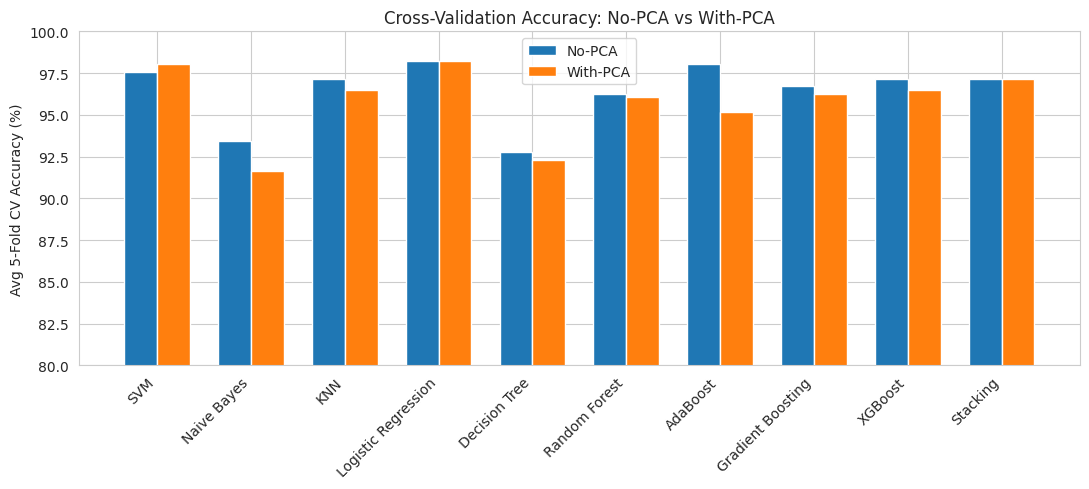

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(cv_comparison))
width = 0.35
ax.bar(x - width/2, cv_comparison["Avg Accuracy No-PCA (%)"], width, label="No-PCA")
ax.bar(x + width/2, cv_comparison["Avg Accuracy With-PCA (%)"], width, label="With-PCA")
ax.set_xticks(x)
ax.set_xticklabels(cv_comparison["Model"], rotation=45, ha="right")
ax.set_ylabel("Avg 5-Fold CV Accuracy (%)")
ax.set_ylim(80, 100)
ax.set_title("Cross-Validation Accuracy: No-PCA vs With-PCA")
ax.legend()
plt.tight_layout()
plt.show()


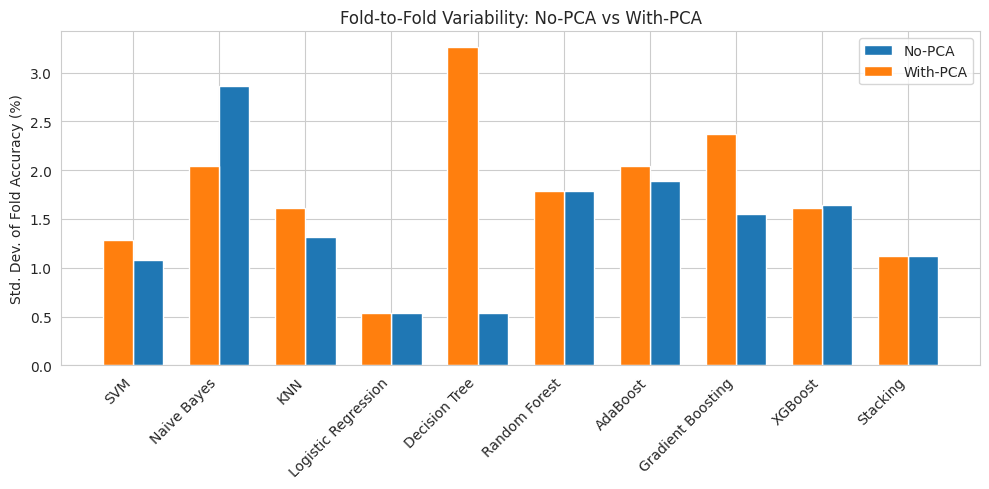

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(cv_comparison["Model"], cv_comparison["Std No-PCA"], width=0.35,
       label="No-PCA", align="edge")
ax.bar(cv_comparison["Model"], cv_comparison["Std With-PCA"], width=-0.35,
       label="With-PCA", align="edge")
ax.set_ylabel("Std. Dev. of Fold Accuracy (%)")
ax.set_title("Fold-to-Fold Variability: No-PCA vs With-PCA")
plt.xticks(rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()


In [16]:
selected_models = ["SVM", "Random Forest", "XGBoost", "Stacking"]

test_results = []
fitted_no_pca = {}
fitted_with_pca = {}

for name in selected_models:
    m_no_pca = results_no_pca[name]["best_estimator"]
    m_with_pca = results_with_pca[name]["best_estimator"]

    m_no_pca.fit(X_train_scaled, y_train)
    m_with_pca.fit(X_train_pca, y_train)

    fitted_no_pca[name] = m_no_pca
    fitted_with_pca[name] = m_with_pca

    for setting, model, X_te in [("No-PCA", m_no_pca, X_test_scaled), ("With-PCA", m_with_pca, X_test_pca)]:
        y_pred = model.predict(X_te)
        y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None
        test_results.append({
            "Model": name, "Setting": setting,
            "Accuracy (%)": accuracy_score(y_test, y_pred) * 100,
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1 Score": f1_score(y_test, y_pred),
            "AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan,
        })

test_results_df = pd.DataFrame(test_results)
test_results_df


,Model,Setting,Accuracy (%),Precision,Recall,F1 Score,AUC
0,SVM,No-PCA,98.245614,0.986111,0.986111,0.986111,0.993717
1,SVM,With-PCA,95.614035,0.985507,0.944444,0.964539,0.996032
2,Random Forest,No-PCA,95.614035,0.958904,0.972222,0.965517,0.993882
3,Random Forest,With-PCA,93.859649,0.957746,0.944444,0.951049,0.986442
4,XGBoost,No-PCA,94.736842,0.945946,0.972222,0.958904,0.992725
5,XGBoost,With-PCA,93.859649,0.957746,0.944444,0.951049,0.993056
6,Stacking,No-PCA,97.368421,0.985915,0.972222,0.979021,0.994048
7,Stacking,With-PCA,95.614035,0.971831,0.958333,0.965035,0.991071


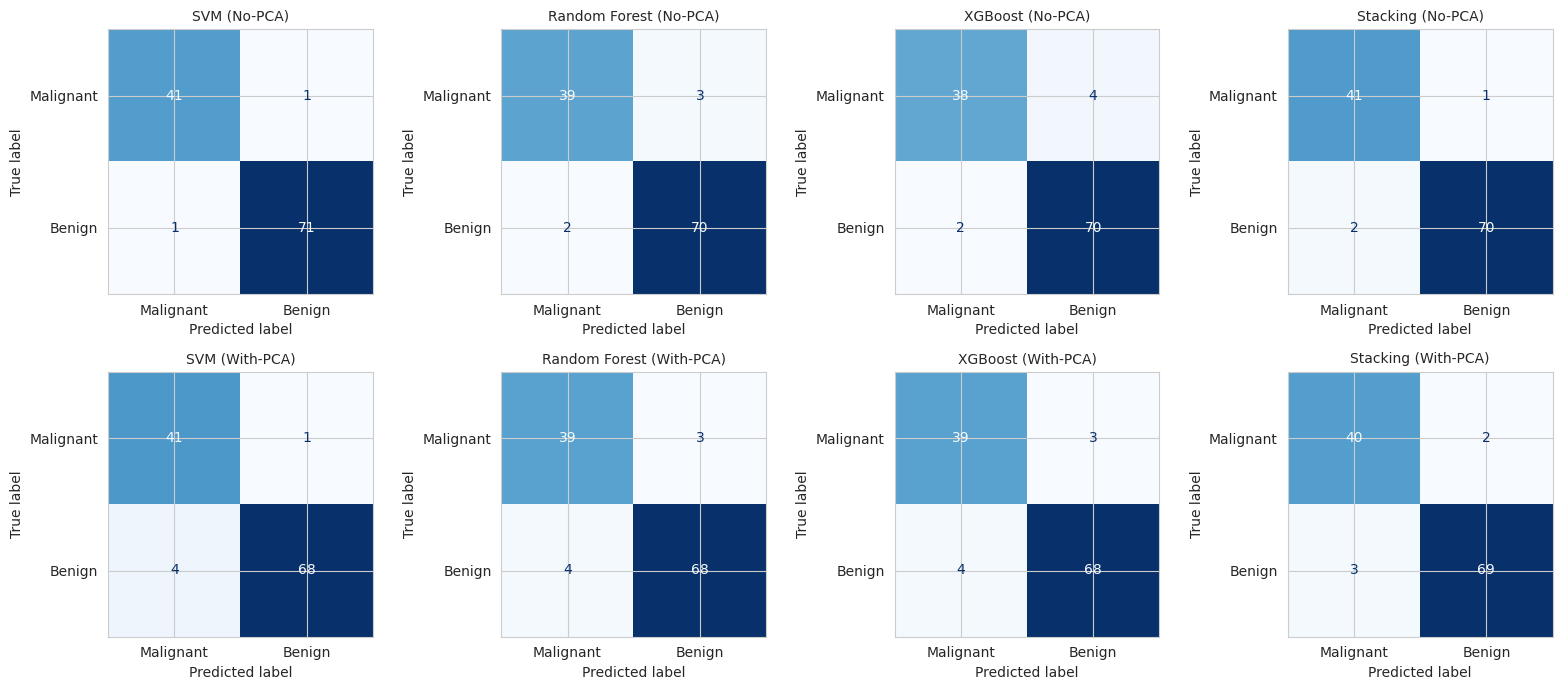

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for col, name in enumerate(selected_models):
    for row, (setting, model, X_te) in enumerate([
        ("No-PCA", fitted_no_pca[name], X_test_scaled),
        ("With-PCA", fitted_with_pca[name], X_test_pca),
    ]):
        cm = confusion_matrix(y_test, model.predict(X_te))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Malignant", "Benign"])
        disp.plot(ax=axes[row, col], colorbar=False, cmap="Blues")
        axes[row, col].set_title(f"{name} ({setting})", fontsize=10)
plt.tight_layout()
plt.show()


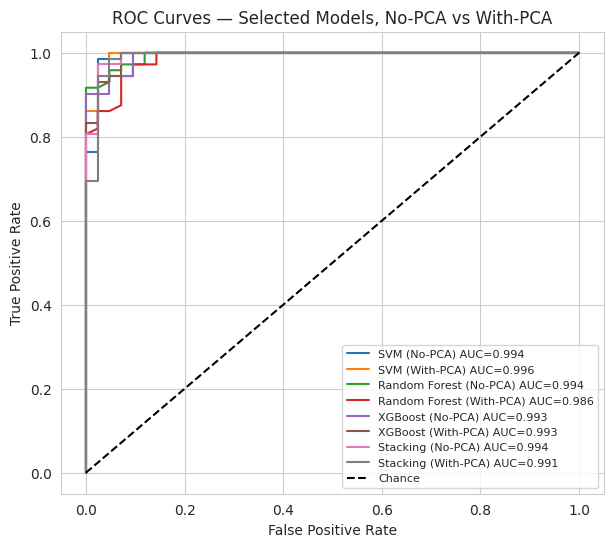

In [18]:
plt.figure(figsize=(7, 6))
for name in selected_models:
    for setting, model, X_te in [("No-PCA", fitted_no_pca[name], X_test_scaled),
                                   ("With-PCA", fitted_with_pca[name], X_test_pca)]:
        y_proba = model.predict_proba(X_te)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} ({setting}) AUC={auc:.3f}")

plt.plot([0, 1], [0, 1], "k--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Selected Models, No-PCA vs With-PCA")
plt.legend(fontsize=8, loc="lower right")
plt.show()
